In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Label mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2}
class_weight: {np.int64(0): np.float64(0.9501915708812261), np.int64(1): np.float64(0.5649202733485194), np.int64(2): np.float64(5.636363636363637)}

===== Linear SVM =====
              precision    recall  f1-score   support

           1      0.396     0.365     0.380        52
           2      0.619     0.682     0.649        88
           3      0.250     0.111     0.154         9

    accuracy                          0.537       149
   macro avg      0.421     0.386     0.394       149
weighted avg      0.519     0.537     0.525       149

Confusion:
 [[19 31  2]
 [27 60  1]
 [ 2  6  1]]
AUC (macro): 0.5712327376177301


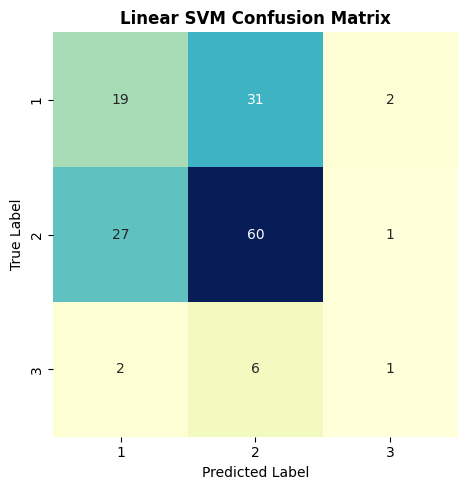

🖼️ Confusion matrix saved to: /content/drive/MyDrive/outputs/rna_linear_svm_cm.jpg


===== Logistic Regression (L1 - Lasso) =====
              precision    recall  f1-score   support

           1      0.377     0.385     0.381        52
           2      0.586     0.580     0.583        88
           3      0.111     0.111     0.111         9

    accuracy                          0.483       149
   macro avg      0.358     0.358     0.358       149
weighted avg      0.485     0.483     0.484       149

Confusion:
 [[20 30  2]
 [31 51  6]
 [ 2  6  1]]
AUC (macro): 0.5691819133301302


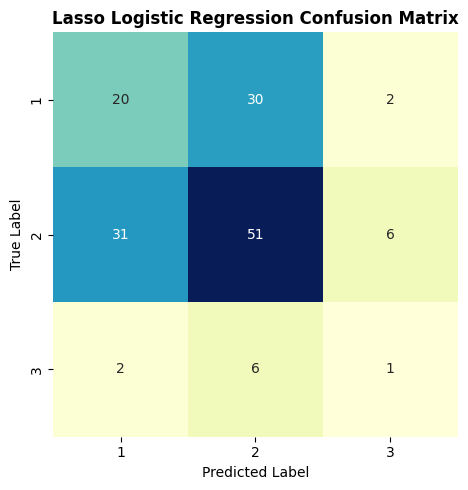

🖼️ Confusion matrix saved to: /content/drive/MyDrive/outputs/rna_lasso_logistic_regression_cm.jpg


===== Logistic (ElasticNet, SMOTE, k=1000) =====
              precision    recall  f1-score   support

           1      0.400     0.385     0.392        52
           2      0.618     0.625     0.621        88
           3      0.000     0.000     0.000         9

    accuracy                          0.503       149
   macro avg      0.339     0.337     0.338       149
weighted avg      0.505     0.503     0.504       149

Confusion:
 [[20 29  3]
 [26 55  7]
 [ 4  5  0]]
AUC (macro): 0.5779284836746389


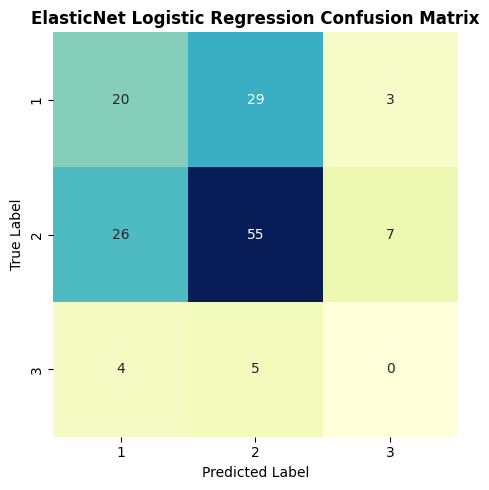

🖼️ Confusion matrix saved to: /content/drive/MyDrive/outputs/rna_elasticnet_logistic_regression_cm.jpg


===== XGBoost =====
              precision    recall  f1-score   support

           1      0.450     0.346     0.391        52
           2      0.638     0.761     0.694        88
           3      0.250     0.111     0.154         9

    accuracy                          0.577       149
   macro avg      0.446     0.406     0.413       149
weighted avg      0.549     0.577     0.556       149

Confusion:
 [[18 33  1]
 [19 67  2]
 [ 3  5  1]]
AUC (macro): 0.5826043306776787


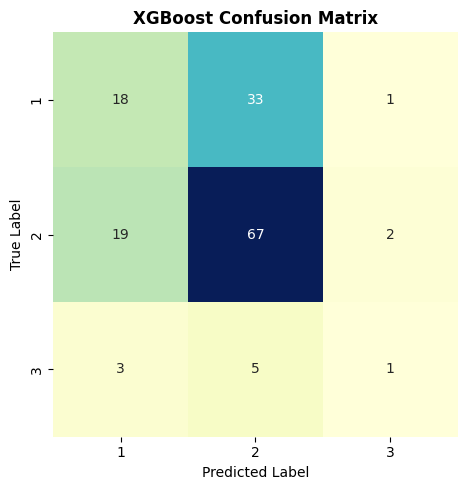

🖼️ Confusion matrix saved to: /content/drive/MyDrive/outputs/rna_xgboost_cm.jpg



In [ ]:
# ==========================================================
# RNA Classification Baseline Models
# ==========================================================
# This script benchmarks several traditional machine learning
# algorithms (SVM, Logistic Regression, XGBoost) for classifying
# Alzheimer's stages (CN/MCI/AD) using mRNA expression data.
# Each model includes:
#  - Feature selection (ANOVA F-test)
#  - Standardization
#  - SMOTE for class imbalance
#  - Class weighting
#  - Confusion matrix visualization and local saving
# ==========================================================

import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt, seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# ==========================================================
# 1. Load dataset
# ==========================================================
file_path = "/content/drive/MyDrive/RNA_cleaned.csv"
SAVE_DIR = "/content/drive/MyDrive/outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(file_path)

# Separate features and target label
# Drop non-numerical and ID columns
X = df.drop(columns=["DIAGNOSIS", "subject_id"])
y = df["DIAGNOSIS"].astype(int)

# Encode labels to 0..K-1 (required for XGBoost multi-class)
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

# ==========================================================
# 2. Train-test split (stratified to preserve class ratio)
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# ==========================================================
# 3. Compute class weights for unbalanced datasets
# ==========================================================
# Ensures that minority classes are not ignored during training
classes = np.unique(y_enc)
cw = compute_class_weight("balanced", classes=classes, y=y_enc)
cw_dict = {c: w for c, w in zip(classes, cw)}
print("class_weight:", cw_dict)

# ==========================================================
# 4. Define SMOTE strategy (synthetic oversampling)
# ==========================================================
unique, counts = np.unique(y_train, return_counts=True)
maxc = counts.max()  # target number of samples per class
smote_dict = {int(k): int(maxc) for k in unique}
smote = SMOTE(random_state=42, sampling_strategy=smote_dict)

# ==========================================================
# 5. Common preprocessing steps
# ==========================================================
# - Feature selection (ANOVA F-test)
# - Standardization (mean=0, std=1)
K_FEATURES = 1000  # can be tuned (e.g., 500, 1000, 2000)
selector = SelectKBest(f_classif, k=K_FEATURES)
scaler   = StandardScaler()

# ==========================================================
# Helper function: plot and save confusion matrix
# ==========================================================
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(le.inverse_transform(y_true), le.inverse_transform(y_pred))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
                xticklabels=le.classes_, yticklabels=le.classes_, square=True)
    plt.xlabel("Predicted Label"); plt.ylabel("True Label")
    plt.title(f"{model_name} Confusion Matrix", weight='bold')
    plt.tight_layout()
    save_path = os.path.join(SAVE_DIR, f"rna_{model_name.lower().replace(' ', '_')}_cm.jpg")
    plt.savefig(save_path, dpi=400, bbox_inches='tight')
    plt.show()
    print(f"🖼️ Confusion matrix saved to: {save_path}\n")

# ==========================================================
# 6. Model 1 — Linear SVM
# ==========================================================
# Linear kernel SVM is a strong baseline for high-dimensional data
# like gene expression (RNA), often performing well with few samples.
svm_pipe = ImbPipeline([
    ("sel", selector),
    ("sc", scaler),
    ("smote", smote),
    ("clf", SVC(kernel="linear", probability=True,
                class_weight=cw_dict, random_state=42))
])
svm_pipe.fit(X_train, y_train)

# Predictions and probabilities
svm_pred  = svm_pipe.predict(X_test)
svm_proba = svm_pipe.predict_proba(X_test)

# Evaluation
print("\n===== Linear SVM =====")
print(classification_report(le.inverse_transform(y_test),
                            le.inverse_transform(svm_pred), digits=3))
print("Confusion:\n", confusion_matrix(le.inverse_transform(y_test),
                                       le.inverse_transform(svm_pred)))
print("AUC (macro):", roc_auc_score(y_test, svm_proba, multi_class="ovr", average="macro"))
plot_confusion_matrix(y_test, svm_pred, "Linear SVM")

# ==========================================================
# 7. Model 2 — Logistic Regression (L1 regularization)
# ==========================================================
# L1 regularization (Lasso) encourages sparsity, helping to select
# only the most relevant genes and reduce overfitting.
log1_pipe = ImbPipeline([
    ("sel", selector),
    ("sc", scaler),
    ("smote", smote),
    ("clf", LogisticRegression(penalty="l1", solver="saga",
                               max_iter=5000, class_weight=cw_dict,
                               random_state=42))
])
log1_pipe.fit(X_train, y_train)
log1_pred  = log1_pipe.predict(X_test)
log1_proba = log1_pipe.predict_proba(X_test)

print("\n===== Logistic Regression (L1 - Lasso) =====")
print(classification_report(le.inverse_transform(y_test),
                            le.inverse_transform(log1_pred), digits=3))
print("Confusion:\n", confusion_matrix(le.inverse_transform(y_test),
                                       le.inverse_transform(log1_pred)))
print("AUC (macro):", roc_auc_score(y_test, log1_proba, multi_class="ovr", average="macro"))
plot_confusion_matrix(y_test, log1_pred, "Lasso Logistic Regression")

# ==========================================================
# 8. Model 3 — Logistic Regression (Elastic Net)
# ==========================================================
# ElasticNet combines L1 and L2 penalties, balancing sparsity and
# stability. It can outperform pure L1 when many features are correlated.
logen_pipe = ImbPipeline([
    ("sel", selector),
    ("sc", scaler),
    ("smote", smote),
    ("clf", LogisticRegression(penalty="elasticnet", l1_ratio=0.5,
                               solver="saga", max_iter=5000,
                               class_weight=cw_dict, random_state=42))
])
logen_pipe.fit(X_train, y_train)
logen_pred  = logen_pipe.predict(X_test)
logen_proba = logen_pipe.predict_proba(X_test)

print("\n===== Logistic (ElasticNet, SMOTE, k=1000) =====")
print(classification_report(le.inverse_transform(y_test),
                            le.inverse_transform(logen_pred), digits=3))
print("Confusion:\n", confusion_matrix(le.inverse_transform(y_test),
                                       le.inverse_transform(logen_pred)))
print("AUC (macro):", roc_auc_score(y_test, logen_proba, multi_class="ovr", average="macro"))
plot_confusion_matrix(y_test, logen_pred, "ElasticNet Logistic Regression")

# ==========================================================
# 9. Model 4 — XGBoost
# ==========================================================
# Gradient boosting trees can capture nonlinear feature interactions.
# Here we use the multi-class softprob objective for probability output.
xgb = XGBClassifier(
    objective="multi:softprob",
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_lambda=1.0, reg_alpha=0.0,
    eval_metric="mlogloss", random_state=42, tree_method="hist"
)

xgb_pipe = ImbPipeline([
    ("sel", selector),
    ("sc", scaler),
    ("smote", smote),
    ("clf", xgb)
])

# Train model with SMOTE-applied data
xgb_pipe.fit(X_train, y_train)
xgb_pred  = xgb_pipe.predict(X_test)
xgb_proba = xgb_pipe.predict_proba(X_test)

print("\n===== XGBoost =====")
print(classification_report(le.inverse_transform(y_test),
                            le.inverse_transform(xgb_pred), digits=3))
print("Confusion:\n", confusion_matrix(le.inverse_transform(y_test),
                                       le.inverse_transform(xgb_pred)))
print("AUC (macro):", roc_auc_score(y_test, xgb_proba, multi_class="ovr", average="macro"))
plot_confusion_matrix(y_test, xgb_pred, "XGBoost")


✅ Using device: cuda
Class counts: [209 351  35]
Class weights: [0.94896334 0.5650522  5.6666665 ]

===== Trial 1/5: {'lr': 0.001, 'hidden_layers': [256, 128, 64], 'dropout': 0.3, 'batch_size': 16} =====
Epoch 01/40 | Loss=1.1316 | Val Acc=0.302
Epoch 02/40 | Loss=1.0172 | Val Acc=0.383
Epoch 03/40 | Loss=1.1705 | Val Acc=0.329
Epoch 04/40 | Loss=0.8268 | Val Acc=0.362
Epoch 05/40 | Loss=0.5549 | Val Acc=0.409
Epoch 06/40 | Loss=1.3436 | Val Acc=0.396
Epoch 07/40 | Loss=0.9198 | Val Acc=0.409
Epoch 08/40 | Loss=0.6203 | Val Acc=0.369
Epoch 09/40 | Loss=1.7009 | Val Acc=0.409
Epoch 10/40 | Loss=0.7129 | Val Acc=0.483
Epoch 11/40 | Loss=1.6323 | Val Acc=0.517
Epoch 12/40 | Loss=0.9338 | Val Acc=0.550
Epoch 13/40 | Loss=1.0195 | Val Acc=0.584
Epoch 14/40 | Loss=0.7462 | Val Acc=0.597
Epoch 15/40 | Loss=0.2276 | Val Acc=0.477
Epoch 16/40 | Loss=0.1909 | Val Acc=0.570
Epoch 17/40 | Loss=1.4169 | Val Acc=0.537
Epoch 18/40 | Loss=1.0192 | Val Acc=0.544
Epoch 19/40 | Loss=0.0727 | Val Acc=0.56

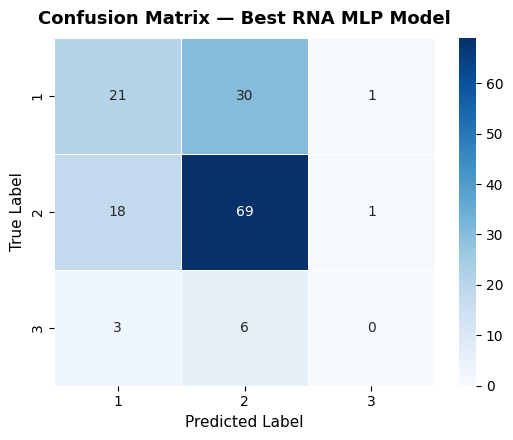

✅ Confusion matrix saved to: /content/drive/MyDrive/5703/FL/outputs/best_rna_confusion_matrix.png


In [13]:
# MLP for RNA Classification with GPU and Hyperparameter Search

# - Uses PyTorch with automatic GPU detection
# - Performs random hyperparameter search
# - Includes early stopping and weighted loss for imbalance

import torch
import torch.nn as nn
import torch.optim as optim
import random
import itertools
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# 1. Load and preprocess dataset
PATH = "/content/drive/MyDrive/5703/RNA_cleaned.csv"
df = pd.read_csv(PATH)

# Drop identifiers; keep features (gene expressions)
X = df.drop(columns=["DIAGNOSIS", "subject_id"])
# Diagnosis (target variable): CN=1, MCI=2, AD=3
y = df["DIAGNOSIS"].astype(int)

# Encode class labels to 0,1,2 for PyTorch training
le = LabelEncoder()
y_enc = le.fit_transform(y)
n_classes = len(np.unique(y_enc))

# Stratified split ensures class proportions remain consistent
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Standardize each gene’s expression (zero mean, unit variance)
# → ensures faster and more stable convergence
sc = StandardScaler().fit(X_train)
X_train = sc.transform(X_train).astype("float32")
X_test  = sc.transform(X_test).astype("float32")

# Convert numpy arrays to PyTorch tensors
X_train = torch.tensor(X_train)
X_test  = torch.tensor(X_test)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

# 2. GPU / device setup
# Automatically select GPU if available (CUDA), else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

# Move all data tensors to the selected device
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

# 3. Class weights for imbalanced data
# Compute number of samples per class
class_counts = np.bincount(y_train.cpu().numpy())
# Weight inversely proportional to class frequency
# → helps the model pay more attention to minority classes
weights = len(y_train) / (n_classes * class_counts)
weights = torch.tensor(weights, dtype=torch.float32).to(device)
print("Class counts:", class_counts)
print("Class weights:", weights.cpu().numpy())

# 4. Define hyperparameter search space
# Grid defines different architectural and training configurations
param_grid = {
    "lr": [1e-2, 5e-3, 1e-3], # Learning rates
    "hidden_layers": [ # Layer configurations
        [512, 256, 128],
        [1024, 512],
        [256, 128, 64],
    ],
    "dropout": [0.1, 0.2, 0.3], # Dropout probability for regularization
    "batch_size": [16, 32, 64], # Mini-batch sizes
}

# Randomly select a few parameter combinations for trial
n_samples = 5
keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
random.shuffle(param_combinations)
param_combinations = param_combinations[:n_samples]

# 5. Define model class
class RNA_MLP(nn.Module):
    def __init__(self, n_features, n_classes, hidden_layers, dropout):
        super().__init__()
        layers = []
        in_dim = n_features
        # Build sequential layers dynamically based on hidden_layers list
        for h in hidden_layers:
            layers += [
                nn.Linear(in_dim, h), # Fully connected layer
                nn.BatchNorm1d(h), # Normalize activations → stabilizes training
                nn.ReLU(), # Non-linearity to capture complex patterns
                nn.Dropout(dropout)] # Prevents overfitting
            in_dim = h
        # Final classification layer
        layers += [nn.Linear(in_dim, n_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Forward pass through the network
        return self.net(x)

# 6. Hyperparameter search loop — Save best epoch predictions
EPOCHS = 40
patience = 5
best_acc, best_params = 0, None
best_model_state = None
best_preds_global, best_true_global = None, None

for t, params in enumerate(param_combinations, 1):
    print(f"\n===== Trial {t}/{len(param_combinations)}: {params} =====")

    model = RNA_MLP(X_train.shape[1], n_classes,
                    params["hidden_layers"], params["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=params["lr"], weight_decay=1e-4)

    best_trial_acc, wait = 0, 0
    best_epoch_state = None
    best_preds, best_true = None, None

    for epoch in range(EPOCHS):
        model.train()
        idx = torch.randperm(len(X_train))
        for i in range(0, len(X_train), params["batch_size"]):
            b_idx = idx[i:i+params["batch_size"]]
            out = model(X_train[b_idx])
            loss = criterion(out, y_train[b_idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # === Validation ===
        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(X_test), dim=1)
            acc = accuracy_score(y_test.cpu(), preds.cpu())

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss={loss.item():.4f} | Val Acc={acc:.3f}")

        # --- Early Stopping + Save Best Epoch Results ---
        if acc > best_trial_acc:
            best_trial_acc, wait = acc, 0
            best_epoch_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_preds = preds.cpu().numpy().copy()
            best_true  = y_test.cpu().numpy().copy()
        else:
            wait += 1
            if wait >= patience:
                print("→ Early stopping for this trial.")
                break

    print(f"Trial {t} best accuracy (best epoch): {best_trial_acc:.4f}")

    # --- 更新全局最佳 ---
    if best_trial_acc > best_acc:
        best_acc = best_trial_acc
        best_params = params
        best_model_state = best_epoch_state
        best_preds_global = best_preds
        best_true_global  = best_true


# 7. Print best result and plot confusion matrix
print("\n🏆 Best trial result:")
print("Best Accuracy:", round(best_acc, 4))
print("Best Parameters:", best_params)

print("\n📊 Confusion Matrix (Best Model)")
cm = confusion_matrix(best_true_global, best_preds_global)
print(cm)
print("\n", classification_report(best_true_global, best_preds_global,
                                   target_names=le.classes_.astype(str)))

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.6, linecolor="white", cbar=True)
plt.title("Confusion Matrix — Best RNA MLP Model", fontsize=13, fontweight="bold", pad=10)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()

save_path = "/content/drive/MyDrive/5703/FL/outputs"
os.makedirs(save_path, exist_ok=True)
plt.savefig(f"{save_path}/best_rna_confusion_matrix.png", dpi=400, bbox_inches="tight")
plt.show()

print(f"✅ Confusion matrix saved to: {save_path}/best_rna_confusion_matrix.png")


[MLP] Epoch 10/40 | Loss=0.0078
[MLP] Epoch 20/40 | Loss=0.0034
[MLP] Epoch 30/40 | Loss=0.0037
[MLP] Epoch 40/40 | Loss=0.0004

✅ Final Accuracy: 0.557

Classification Report:
               precision    recall  f1-score   support

           1      0.447     0.404     0.424        52
           2      0.642     0.693     0.667        88
           3      0.143     0.111     0.125         9

    accuracy                          0.557       149
   macro avg      0.411     0.403     0.405       149
weighted avg      0.544     0.557     0.549       149

Confusion Matrix:
 [[21 29  2]
 [23 61  4]
 [ 3  5  1]]


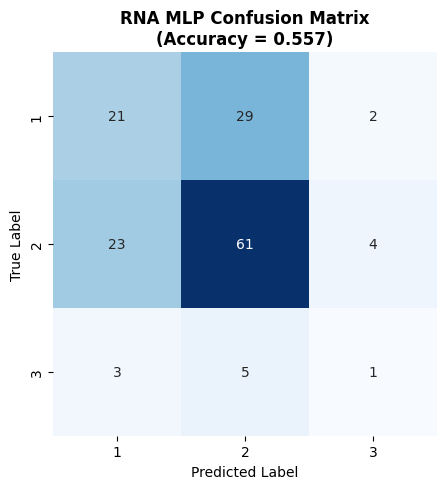


🖼️ Confusion matrix saved to: /content/drive/MyDrive/outputs/rna_mlp_confusion_matrix.jpg


In [ ]:
# ==========================================================
# RNA Classification with Multi-Layer Perceptron (MLP)
# ==========================================================
# This script trains a feedforward neural network (MLP)
# to classify Alzheimer's stages (CN / MCI / AD) based on mRNA expression data.
# It performs feature standardization, label encoding, model training,
# and final evaluation including confusion matrix visualization.
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Configuration & Paths
EPOCHS = 40                  # total training epochs
BATCH = 32                   # mini-batch size
LR = 1e-3                    # learning rate
SAVE_DIR = "/content/drive/MyDrive/outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# 2. Load and Prepare Dataset
PATH = "/content/drive/MyDrive/5703/RNA_cleaned.csv"
df = pd.read_csv(PATH)

# Drop identifier columns, retain mRNA expression features
X = df.drop(columns=["DIAGNOSIS", "subject_id"], errors='ignore')
y = df["DIAGNOSIS"].astype(int)

# Encode categorical labels (CN/MCI/AD) into integers 0,1,2
le = LabelEncoder()
y_enc = le.fit_transform(y)
n_classes = len(np.unique(y_enc))

# Stratified train-test split ensures similar class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Standardize features (zero mean, unit variance)
# → Ensures equal contribution of all features during optimization
sc = StandardScaler().fit(X_train)
X_train = sc.transform(X_train).astype("float32")
X_test  = sc.transform(X_test).astype("float32")

# Convert to PyTorch tensors for GPU/CPU computation
X_train = torch.tensor(X_train)
X_test  = torch.tensor(X_test)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

# 3. Define MLP Model
class RNA_MLP(nn.Module):
    """
    A simple feedforward neural network with 3 hidden layers.
    Each layer applies linear transformation + ReLU + Dropout regularization.
    """
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate model
model = RNA_MLP(X_train.shape[1], n_classes)

# 4. Define Loss Function & Optimizer
# CrossEntropyLoss automatically applies Softmax internally
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# 5. Training Loop
for epoch in range(EPOCHS):
    model.train()
    idx = torch.randperm(len(X_train))
    total_loss = 0.0
    # Mini-batch training
    for i in range(0, len(X_train), BATCH):
        batch_idx = idx[i:i+BATCH]
        out = model(X_train[batch_idx])
        loss = criterion(out, y_train[batch_idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    # Print progress every 10 epochs
    if (epoch+1) % 10 == 0:
        print(f"[MLP] Epoch {epoch+1}/{EPOCHS} | Loss={total_loss/len(idx):.4f}")

# 6. Evaluation
# Switch to evaluation mode (disable dropout/batchnorm updates)
model.eval()
with torch.no_grad():
    logits = model(X_test)
    preds = torch.argmax(logits, dim=1).numpy()
    y_true = y_test.numpy()

# Compute metrics
acc = accuracy_score(y_true, preds)
print(f"\n✅ Final Accuracy: {acc:.3f}")
print("\nClassification Report:\n", classification_report(
    le.inverse_transform(y_true), le.inverse_transform(preds), digits=3))
print("Confusion Matrix:\n", confusion_matrix(
    le.inverse_transform(y_true), le.inverse_transform(preds)))

# 7. Confusion Matrix Visualization & Save
cm = confusion_matrix(le.inverse_transform(y_true), le.inverse_transform(preds))
classes = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=classes, yticklabels=classes, square=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"RNA MLP Confusion Matrix\n(Accuracy = {acc:.3f})", weight='bold')
plt.tight_layout()

# Save as .jpg
save_path = os.path.join(SAVE_DIR, "rna_mlp_confusion_matrix.jpg")
plt.savefig(save_path, dpi=400, bbox_inches="tight")
plt.show()

print(f"\n🖼️ Confusion matrix saved to: {save_path}")


[CNN1D] Epoch 001 | Loss=0.9575 | Acc=0.5906 | BalAcc=0.3333 | F1(macro)=0.2475
[CNN1D] Epoch 010 | Loss=0.8662 | Acc=0.5906 | BalAcc=0.3333 | F1(macro)=0.2475
Early stopping triggered

=== FINAL RESULTS (CNN1D - No Class Imbalance Handling) ===
Final Accuracy: 0.5906040268456376
Final Balanced Accuracy: 0.3333333333333333
Final Macro F1: 0.24753867791842477

Classification Report:
               precision    recall  f1-score   support

           1      0.000     0.000     0.000        52
           2      0.591     1.000     0.743        88
           3      0.000     0.000     0.000         9

    accuracy                          0.591       149
   macro avg      0.197     0.333     0.248       149
weighted avg      0.349     0.591     0.439       149

Confusion Matrix:
 [[ 0 52  0]
 [ 0 88  0]
 [ 0  9  0]]


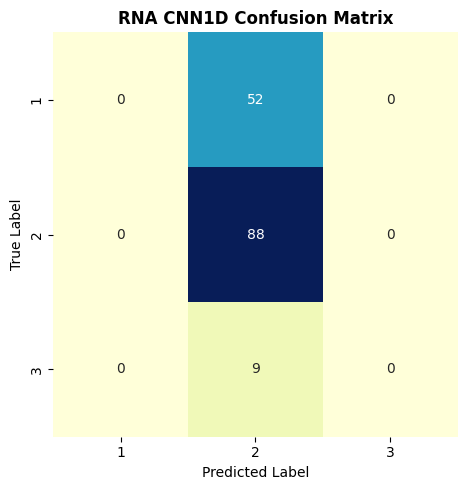


🖼️ Confusion matrix saved to: /content/drive/MyDrive/outputs/rna_cnn1d_confusion_matrix.jpg


In [ ]:
# RNA Classification with CNN1D (No Class Imbalance Handling)
# This script trains a 1D Convolutional Neural Network (CNN)
# to classify Alzheimer's stages (CN / MCI / AD) based on mRNA expression data.
# Unlike other versions, this one does not apply class weighting or resampling
# to handle data imbalance.
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Load dataset
PATH = "/content/drive/MyDrive/RNA_cleaned.csv"
SAVE_DIR = "/content/drive/MyDrive/outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(PATH)

# Drop non-feature columns; retain mRNA expression values
X = df.drop(columns=["DIAGNOSIS", "subject_id"])
# Diagnosis: CN, MCI, AD encoded as integers (1,2,3)
y = df["DIAGNOSIS"].astype(int)

# Encode labels to 0, 1, 2 for PyTorch compatibility
le = LabelEncoder()
y_enc = le.fit_transform(y)   # {1,2,3} -> {0,1,2}
n_classes = len(np.unique(y_enc))

# Split dataset (stratified sampling to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# Standardize each gene feature (zero mean, unit variance)
# → ensures comparable scales and faster convergence
sc = StandardScaler().fit(X_train)
X_train = sc.transform(X_train).astype("float32")
X_test  = sc.transform(X_test).astype("float32")

# Convert numpy arrays to PyTorch tensors
X_train = torch.tensor(X_train)
X_test  = torch.tensor(X_test)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

# 2. DataLoader (no sampler)
# Wrap datasets into TensorDataset and DataLoader for batching
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

# 3. CNN Model
class ImprovedCNN1D(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        # Four convolutional blocks with increasing filter sizes
        # Each block learns higher-level local patterns
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.conv4 = nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm1d(256)

        # Pooling layers reduce spatial dimension and capture hierarchical structure
        self.pool = nn.MaxPool1d(2)
        # AdaptiveAvgPool ensures fixed output size regardless of input length
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Fully connected classifier for final prediction
        self.fc = nn.Sequential(
            nn.Linear(256, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        # Add channel dimension (B, 1, features)
        x = x.unsqueeze(1)
        # Convolutional feature extraction
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = torch.relu(self.bn4(self.conv4(x)))
        # Global average pooling for compact representation
        x = self.global_pool(x).squeeze(-1)
        # Fully connected classification head
        x = self.fc(x)
        return x

# 4. Train & Evaluate
def train_and_eval(model, epochs=100):
    model = model.to("cpu")
    criterion = nn.CrossEntropyLoss() # No class weighting used here
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_bal_acc = 0
    patience, wait = 15, 0 # Early stopping parameters

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        for xb, yb in train_loader:
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # ---- Eval ----
        model.eval()
        all_preds, all_true = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                logits = model(xb)
                preds = torch.argmax(logits, dim=1)
                # Collect predictions and labels for metrics
                all_preds.extend(preds.numpy())
                all_true.extend(yb.numpy())

        # Compute accuracy metrics
        acc = accuracy_score(all_true, all_preds)
        bal_acc = balanced_accuracy_score(all_true, all_preds)
        f1 = f1_score(all_true, all_preds, average="macro")

        # Display progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[CNN1D] Epoch {epoch+1:03d} | Loss={loss.item():.4f} "
                  f"| Acc={acc:.4f} | BalAcc={bal_acc:.4f} | F1(macro)={f1:.4f}")

        # ---- Early stopping logic ----
        if bal_acc > best_bal_acc:
            best_bal_acc = bal_acc
            wait = 0
            torch.save(model.state_dict(), f"{SAVE_DIR}/best_cnn1d.pt")
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered")
                break

    # Final Evaluation on Test Set
    model.load_state_dict(torch.load(f"{SAVE_DIR}/best_cnn1d.pt"))
    model.eval()
    with torch.no_grad():
        logits = model(X_test)
        preds = torch.argmax(logits, dim=1).numpy()
        y_true = y_test.numpy()

    # Print overall metrics and confusion matrix
    print("\n=== FINAL RESULTS (CNN1D - No Class Imbalance Handling) ===")
    print("Final Accuracy:", accuracy_score(y_true, preds))
    print("Final Balanced Accuracy:", balanced_accuracy_score(y_true, preds))
    print("Final Macro F1:", f1_score(y_true, preds, average="macro"))
    print("\nClassification Report:\n", classification_report(le.inverse_transform(y_true), le.inverse_transform(preds), digits=3))
    print("Confusion Matrix:\n", confusion_matrix(le.inverse_transform(y_true), le.inverse_transform(preds)))

    # Confusion Matrix Visualization & Save (.jpg)
    cm = confusion_matrix(le.inverse_transform(y_true), le.inverse_transform(preds))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
                xticklabels=le.classes_, yticklabels=le.classes_, square=True)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("RNA CNN1D Confusion Matrix", weight='bold')
    plt.tight_layout()

    cm_path = os.path.join(SAVE_DIR, "rna_cnn1d_confusion_matrix.jpg")
    plt.savefig(cm_path, dpi=400, bbox_inches='tight')
    plt.show()

    print(f"\n🖼️ Confusion matrix saved to: {cm_path}")

# 5. Run CNN
# Instantiate model and start training
cnn_model = ImprovedCNN1D(X_train.shape[1], n_classes)
train_and_eval(cnn_model, epochs=50)
